In [2]:
!pip install wfdb torch numpy pandas matplotlib scikit-learn tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 71.5 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.3 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.3 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.3 which is incompatible.


In [3]:
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [4]:
wfdb.dl_database('mitdb', dl_dir='mitdb')

Generating record list for: 100
Generating record list for: 101
Generating record list for: 102
Generating record list for: 103
Generating record list for: 104
Generating record list for: 105
Generating record list for: 106
Generating record list for: 107
Generating record list for: 108
Generating record list for: 109
Generating record list for: 111
Generating record list for: 112
Generating record list for: 113
Generating record list for: 114
Generating record list for: 115
Generating record list for: 116
Generating record list for: 117
Generating record list for: 118
Generating record list for: 119
Generating record list for: 121
Generating record list for: 122
Generating record list for: 123
Generating record list for: 124
Generating record list for: 200
Generating record list for: 201
Generating record list for: 202
Generating record list for: 203
Generating record list for: 205
Generating record list for: 207
Generating record list for: 208
Generating record list for: 209
Generati

In [5]:
records = ['100', '101', '102']

signals = []
labels = []

window_size = 128

label_map = {
    'N': 0,
    'V': 1,
    'A': 2,
    'L': 3,
    'R': 4
}

for record_name in records:

    record = wfdb.rdrecord(f'mitdb/{record_name}')
    annotation = wfdb.rdann(f'mitdb/{record_name}', 'atr')

    signal = record.p_signal[:, 0]

    for i, sample in enumerate(annotation.sample):

        symbol = annotation.symbol[i]

        if symbol in label_map:

            if sample-window_size >= 0 and sample+window_size < len(signal):

                beat = signal[sample-window_size : sample+window_size]

                signals.append(beat)

                labels.append(label_map[symbol])

In [6]:
X = np.array(signals)
y = np.array(labels)

print(X.shape)
print(y.shape)

(4236, 256)
(4236,)


In [7]:
X = (X - np.mean(X, axis=1, keepdims=True)) / \
    (np.std(X, axis=1, keepdims=True) + 1e-8)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [9]:
class ECGDataset(Dataset):

    def __init__(self, X, y):
        self.X = X.astype(np.float32)
        self.y = y.astype(np.int64)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):

        x = torch.tensor(self.X[idx], dtype=torch.float32)
        y = torch.tensor(self.y[idx], dtype=torch.long)

        return x, y

In [10]:
train_dataset = ECGDataset(X_train, y_train)
test_dataset = ECGDataset(X_test, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32
)

In [27]:
class AttentionBlock(nn.Module):

    def __init__(self, d_model, nhead):

        super().__init__()

        self.attention = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=nhead,
            batch_first=True
        )

    def forward(self, x):

        attn_output, attn_weights = self.attention(
            x,
            x,
            x,
            need_weights=True
        )

        return attn_output, attn_weights

In [28]:
class CNNTransformer(nn.Module):

    def __init__(
        self,
        d_model=64,
        nhead=4,
        num_layers=2,
        num_classes=5
    ):

        super().__init__()

        # CNN feature extractor
        self.cnn = nn.Sequential(

            nn.Conv1d(
                in_channels=1,
                out_channels=32,
                kernel_size=5,
                padding=2
            ),

            nn.ReLU(),

            nn.MaxPool1d(2),

            nn.Conv1d(
                32,
                d_model,
                kernel_size=5,
                padding=2
            ),

            nn.ReLU(),

            nn.MaxPool1d(2)
        )

        self.attention_block = AttentionBlock(
            d_model=d_model,
            nhead=nhead

        )


        # Classifier
        self.classifier = nn.Sequential(

            nn.Linear(d_model, 64),

            nn.ReLU(),

            nn.Dropout(0.2),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):

        # (batch, seq)
        x = x.unsqueeze(1)

        # CNN
        x = self.cnn(x)

        # (batch, channels, seq)
        x = x.permute(0, 2, 1)

        # attn
        x, attn_weights = self.attention_block(x)

        # Global pooling
        x = x.mean(dim=1)

        return self.classifier(x), attn_weights

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNNTransformer().to(device)

In [30]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

epochs = 10

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs, _ = model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

Epoch 1, Loss: 0.0153
Epoch 1, Loss: 0.0303
Epoch 1, Loss: 0.0450
Epoch 1, Loss: 0.0594
Epoch 1, Loss: 0.0737
Epoch 1, Loss: 0.0874
Epoch 1, Loss: 0.1007
Epoch 1, Loss: 0.1135
Epoch 1, Loss: 0.1254
Epoch 1, Loss: 0.1359
Epoch 1, Loss: 0.1450
Epoch 1, Loss: 0.1532
Epoch 1, Loss: 0.1593
Epoch 1, Loss: 0.1646
Epoch 1, Loss: 0.1662
Epoch 1, Loss: 0.1683
Epoch 1, Loss: 0.1684
Epoch 1, Loss: 0.1684
Epoch 1, Loss: 0.1684
Epoch 1, Loss: 0.1735
Epoch 1, Loss: 0.1735
Epoch 1, Loss: 0.1892
Epoch 1, Loss: 0.1923
Epoch 1, Loss: 0.1972
Epoch 1, Loss: 0.2017
Epoch 1, Loss: 0.2017
Epoch 1, Loss: 0.2017
Epoch 1, Loss: 0.2057
Epoch 1, Loss: 0.2057
Epoch 1, Loss: 0.2057
Epoch 1, Loss: 0.2057
Epoch 1, Loss: 0.2072
Epoch 1, Loss: 0.2072
Epoch 1, Loss: 0.2097
Epoch 1, Loss: 0.2097
Epoch 1, Loss: 0.2116
Epoch 1, Loss: 0.2118
Epoch 1, Loss: 0.2138
Epoch 1, Loss: 0.2155
Epoch 1, Loss: 0.2158
Epoch 1, Loss: 0.2162
Epoch 1, Loss: 0.2167
Epoch 1, Loss: 0.2173
Epoch 1, Loss: 0.2177
Epoch 1, Loss: 0.2195
Epoch 1, L

In [43]:
predictions = []
true_labels = []

model.eval()

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        outputs, attention = model(X_batch)

        preds = torch.argmax(outputs, dim=1)

        predictions.extend(
            preds.cpu().numpy()
        )

        true_labels.extend(
            y_batch.numpy()
        )

In [17]:
print(np.unique(true_labels))
print(np.unique(predictions))

[0 1 2]
[0 1]


In [44]:
print(classification_report(
    true_labels,
    predictions,
    labels=[0,1,2],
    target_names=[
        'Normal',
        'PVC',
        'APB'
    ],
    zero_division=0
))

              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00       840
         PVC       0.00      0.00      0.00         1
         APB       0.00      0.00      0.00         7

    accuracy                           0.99       848
   macro avg       0.33      0.33      0.33       848
weighted avg       0.98      0.99      0.99       848



In [45]:
cm = confusion_matrix(
    true_labels,
    predictions
)

print(cm)

[[840   0   0]
 [  1   0   0]
 [  7   0   0]]


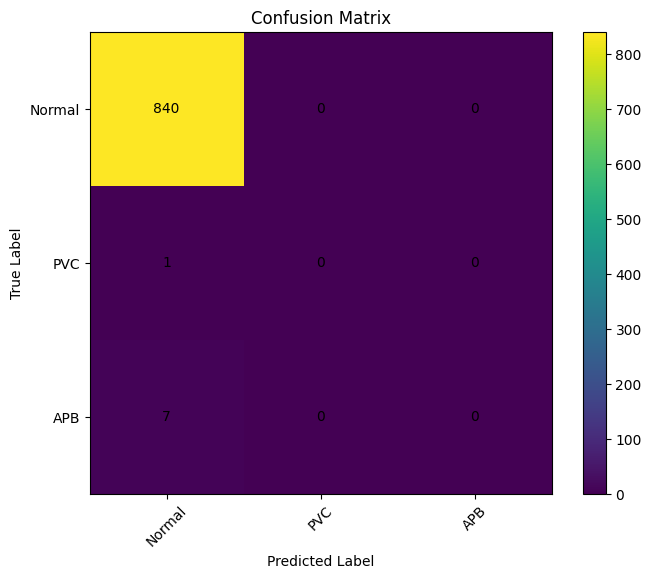

In [46]:
class_names = [
    'Normal',
    'PVC',
    'APB'
]

plt.figure(figsize=(8,6))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.colorbar()

tick_marks = np.arange(len(class_names))

plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Add numbers inside cells
for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(
            j,
            i,
            cm[i, j],
            ha='center',
            va='center'
        )

plt.show()

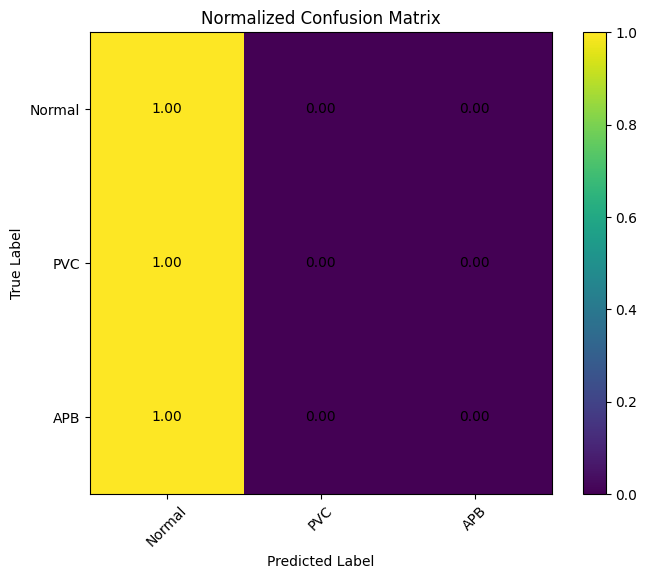

In [50]:
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8,6))

plt.imshow(cm_normalized)

plt.title("Normalized Confusion Matrix")

plt.colorbar()

plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(len(class_names)):
    for j in range(len(class_names)):

        plt.text(
            j,
            i,
            f"{cm_normalized[i, j]:.2f}",
            ha='center',
            va='center'
        )

plt.show()

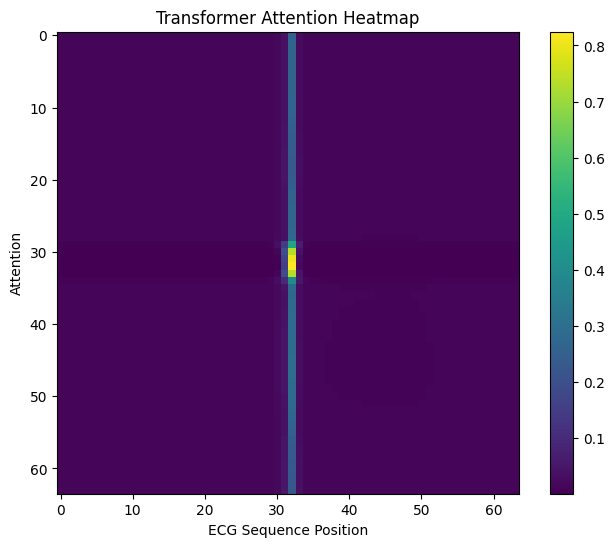

In [48]:
attention_map = attention[0].cpu().numpy()

plt.figure(figsize=(8,6))

plt.imshow(attention_map)

plt.title("Transformer Attention Heatmap")

plt.xlabel("ECG Sequence Position")
plt.ylabel("Attention")

plt.colorbar()

plt.show()

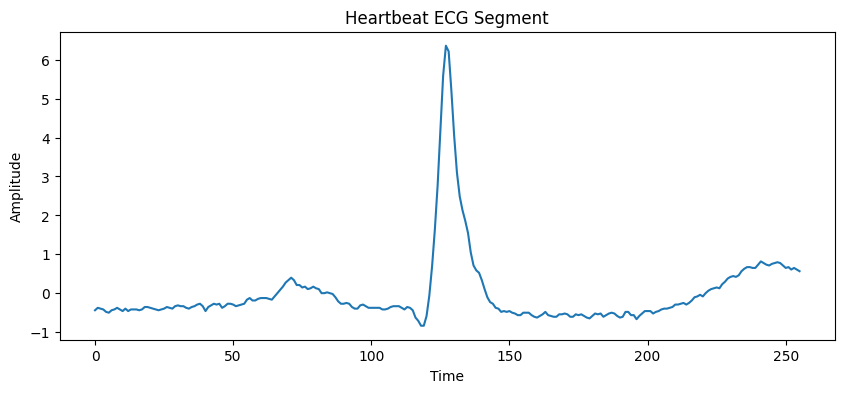

In [49]:
sample_signal = X_test[0]

plt.figure(figsize=(10,4))
plt.plot(sample_signal)

plt.title("Heartbeat ECG Segment")
plt.xlabel("Time")
plt.ylabel("Amplitude")

plt.show()